In [ ]:
#import relevant libraries
import os
#from scipy import stats

import numpy as np
#import scipy as sp
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm
import seaborn as sns
import dabest
import NLCLIMB
import NLMATH
import itertools
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')
from statistics import mean
from textwrap import wrap


import dabest
import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.graph_objects import Layout
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

#NOTE: SUPPRESSES WARNINGS!

import warnings


warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)



In [35]:
homecomp = "D:"
inputdir = homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\Falling_New\\Compilation with delta\\2025deltagcollection\\"

mboncsv = pd.read_csv(homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Data Compilation\\MBONlist.csv").astype("string")
from collections import defaultdict
mbon_lookup = defaultdict(list)
for _, row in mboncsv.iterrows():
    for name in row["MBON names"].split(","):
        mbon_lookup[name.strip()].append(row["MBON number"].strip())

def format_mbon_label(driver):
    nums = sorted(mbon_lookup.get(driver, []))
    if not nums:
        return driver
    label = nums[0]
    for n in nums[1:]:
        label += ", " + n.replace("MBON", "")
    return label + "\n" + driver

def load_forest_data(responder):
    exclude = ["R76B09", "Th-Gal4", "R58", "VT999036"]
    bootstraps, names, diffs, ci_lows, ci_highs = [], [], [], [], []
    for f in os.listdir(inputdir):
        if not f.endswith("_deltag_allstats.csv") or responder not in f:
            continue
        driver = f.split(" ")[0]
        if driver in exclude:
            continue
        df = pd.read_csv(inputdir + f)
        boot = df["fallnumber_bootstrap"].dropna().values
        bootstraps.append(boot)
        names.append(driver)
        diffs.append(df["fallnumber_meandiff"].iloc[0])
        ci_lows.append(np.percentile(boot, 2.5))
        ci_highs.append(np.percentile(boot, 97.5))
    order = np.argsort(diffs)
    return ([bootstraps[i] for i in order], [names[i] for i in order],
            [diffs[i] for i in order], [ci_lows[i] for i in order], [ci_highs[i] for i in order])

#for fonts only
import matplotlib.pyplot as plt
from matplotlib import font_manager

font_dirs = [homecomp + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\"]  # The path to the custom font file.
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)


for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    prop = font_manager.FontProperties(fname=font_file)

availablefonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
plt.rcParams["font.family"] = "Inter"

In [16]:
boots_acr, names_acr, diffs_acr, ci_lo_acr, ci_hi_acr = load_forest_data("ACR")
boots_chr, names_chr, diffs_chr, ci_lo_chr, ci_hi_chr = load_forest_data("Chrimson2")

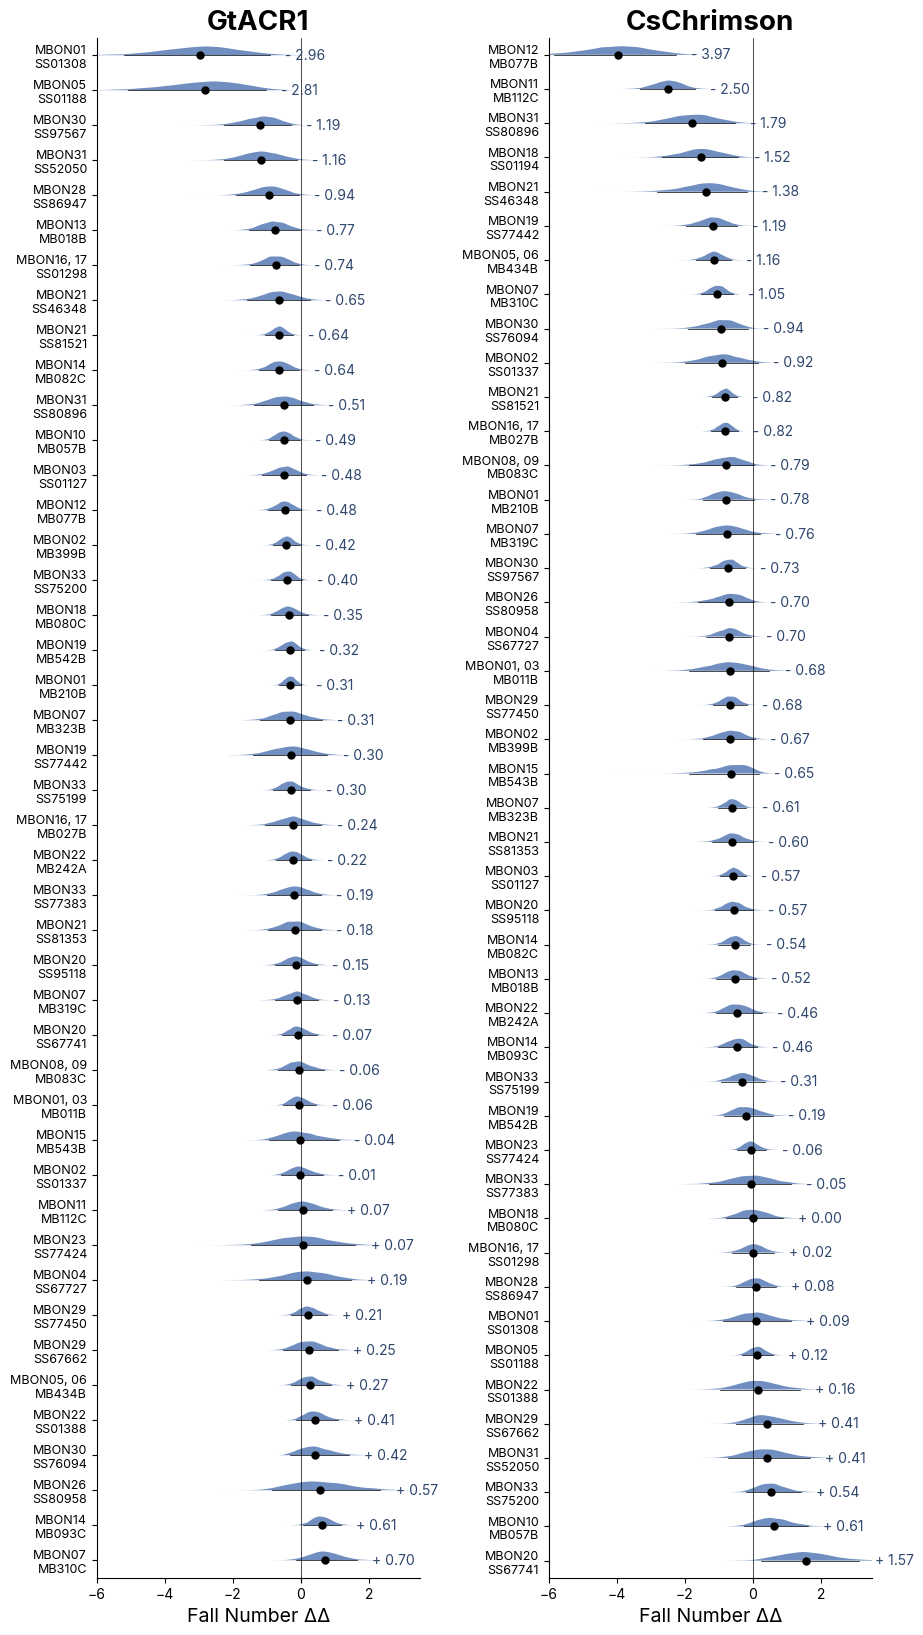

In [ ]:
violin_color = "#4C72B0"
text_color = "#30486E"

fig, axx = plt.subplots(nrows=1, ncols=2, figsize=(10, 20), gridspec_kw={"wspace": 0.4})

for ax, boots, names, diffs, ci_lo, ci_hi, title in zip(
    axx,
    [boots_acr, boots_chr],
    [names_acr, names_chr],
    [diffs_acr, diffs_chr],
    [ci_lo_acr, ci_lo_chr],
    [ci_hi_acr, ci_hi_chr],
    ["GtACR1", "CsChrimson"],
):
    positions = list(range(1, len(names) + 1))
    parts = ax.violinplot(boots, positions=positions, widths=0.5, vert=False, showextrema=False, showmedians=False)
    for pc in parts["bodies"]:
        m = np.mean(pc.get_paths()[0].vertices[:, 1])
        pc.get_paths()[0].vertices[:, 1] = np.clip(pc.get_paths()[0].vertices[:, 1], -np.inf, m)
        pc.set_facecolor(violin_color)
        pc.set_alpha(0.8)

    for pos, diff, lo, hi in zip(positions, diffs, ci_lo, ci_hi):
        ax.plot([lo, hi], [pos, pos], color="black", lw=0.5, zorder=1)
        ax.plot(diff, pos, "o", color="black", markersize=5, zorder=2)
        sign = "+ " if diff >= 0 else "- "
        ax.text(hi + 0.45, pos, f"{sign}{abs(diff):.2f}", va="center", fontsize=10, color=text_color)

    ax.axvline(x=0, color="black", lw=0.5)
    ylabels = [format_mbon_label(n) for n in names]
    ax.set_yticks(positions)
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel("Fall Number ΔΔ", fontsize=14)
    ax.set_title(title, fontsize=20, fontweight="bold")
    ax.set_xlim([-6, 3.5])
    ax.set_ylim(len(names) + 0.5, 0.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
plt.rcParams["font.family"] = "Inter"
matplotlib.rcParams['svg.fonttype'] = 'none'

